<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning-TAE1/blob/main/ML_TAE1_Model_2_7030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Vedant Sangrame**

**Topic: Accident Severity Prediction**

**Model: 2) DecisionTreeClassifier**

Mounted at /content/drive
Original Shape: (150000, 46)
Cleaned Shape: (90562, 9)
Decision Tree Accuracy: 0.7896131620597004


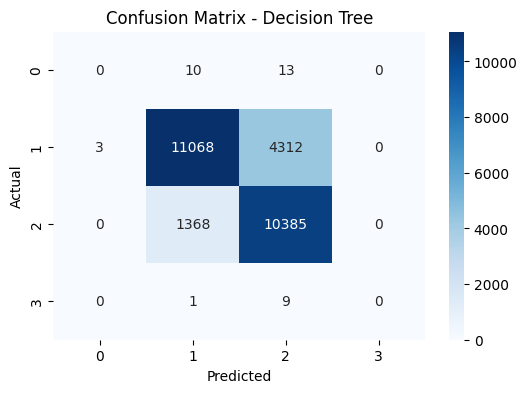

In [ ]:
# ================== STEP 1: IMPORT LIBRARIES ==================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier

from google.colab import drive
drive.mount('/content/drive')


# ================== STEP 2: LOAD DATA ==================
path = "/content/drive/MyDrive/ML_dataset/US_Accidents_March23.csv"
df = pd.read_csv(path, nrows=150000)

print("Original Shape:", df.shape)


# ================== STEP 3: DATA CLEANING ==================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Select important features
data = df[['Severity','Start_Lat','Start_Lng','Distance(mi)',
           'Temperature(F)','Humidity(%)','Pressure(in)',
           'Visibility(mi)','Wind_Speed(mph)']]

# Handle missing values
data = data.dropna()

# Outlier Removal (IQR Method)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Cleaned Shape:", data.shape)


# ================== STEP 4: PREPROCESSING ==================

# Feature & Target
X = data.drop('Severity', axis=1)
y = data['Severity']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling (optional for Decision Tree)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================== STEP 5: MODEL TRAINING ==================

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)


# ================== STEP 6: PREDICTION ==================

y_pred = dt_model.predict(X_test)


# ================== STEP 7: EVALUATION ==================

accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()